Streaming Subscription Churn Prediction

**Goal:** Predict which customers will cancel their streaming subscription so the business can target them with retention strategies.

**Dataset:** 125,000 training records, 75,000 test records from Kaggle. Features include demographics, subscription details, usage behavior, and social engagement.

**Approach:** Feature engineering → XGBoost → Optuna hyperparameter tuning

**Result:** 0.94 AUC on validation set



In [1]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
import optuna
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns



optuna.logging.set_verbosity(optuna.logging.WARNING)

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print(train.shape, test.shape)
train["churned"].value_counts(normalize=True)

(125000, 20) (75000, 19)


churned
1    0.513392
0    0.486608
Name: proportion, dtype: float64

In [2]:
train = train.drop(columns=["customer_id"], errors="ignore")
test = test.drop(columns=["customer_id"], errors="ignore")

target = "churned"
X = train.drop(columns=[target])
y = train[target]

## Exploratory Data Analysis

Before modeling, we examine how key features relate to churn to guide feature engineering decisions.

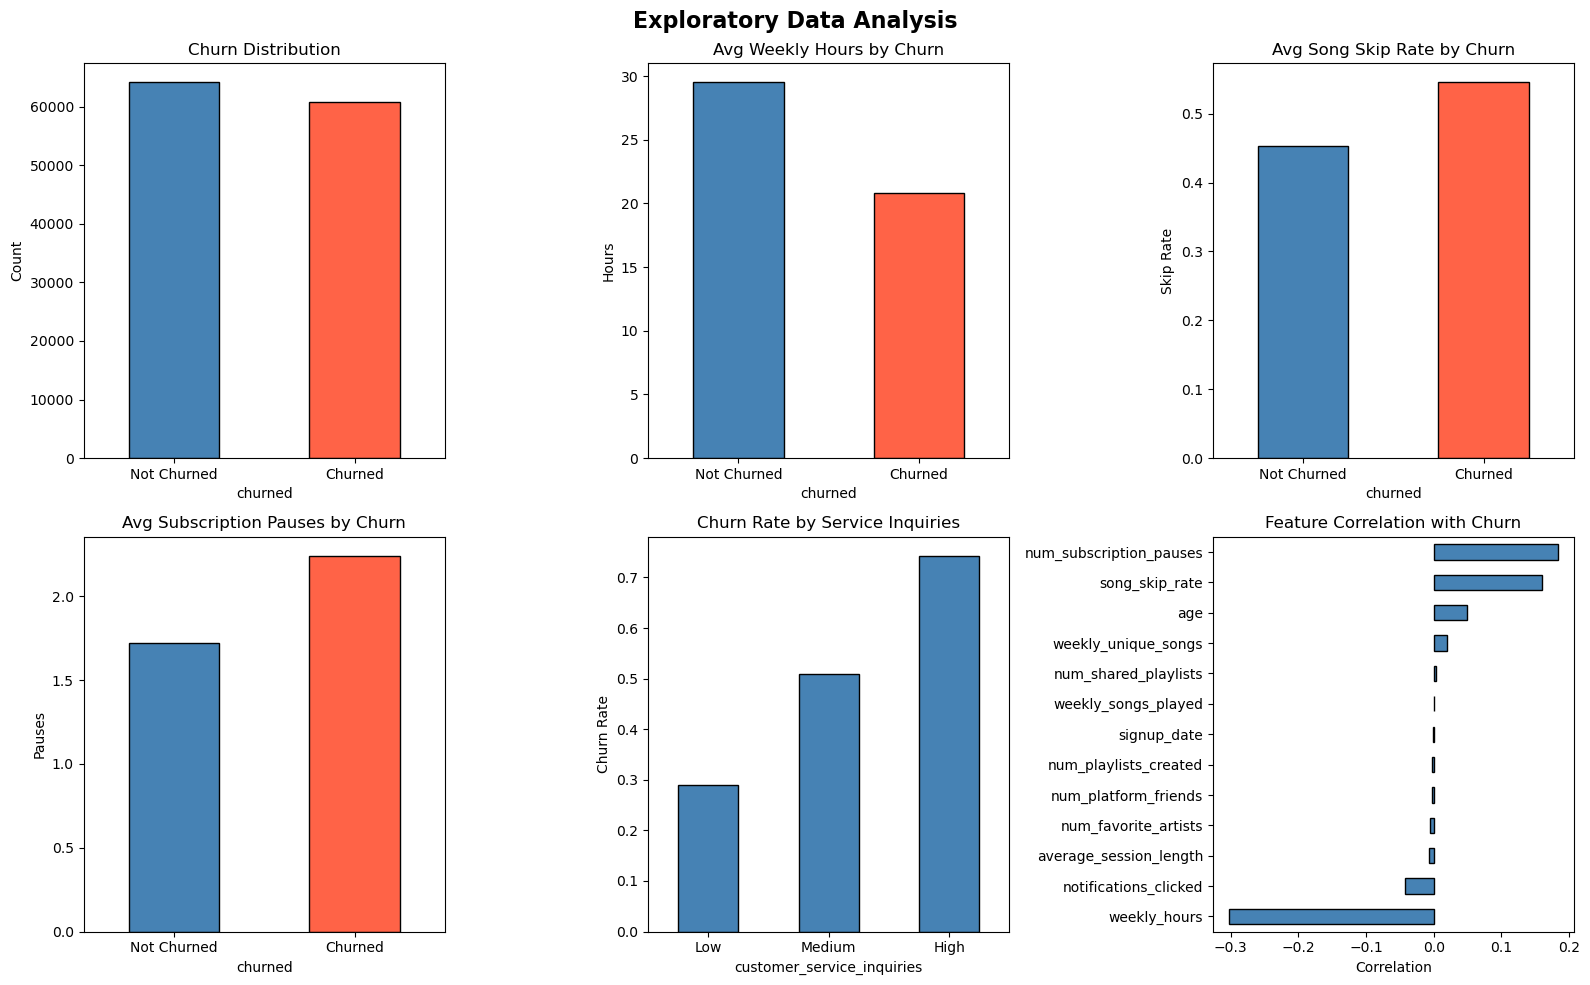

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Exploratory Data Analysis", fontsize=16, fontweight="bold")

# Churn rate
ax = axes[0, 0]
y.value_counts().plot(kind="bar", ax=ax, color=["steelblue", "tomato"], edgecolor="black")
ax.set_title("Churn Distribution")
ax.set_xticklabels(["Not Churned", "Churned"], rotation=0)
ax.set_ylabel("Count")

# Weekly hours by churn
ax = axes[0, 1]
train.groupby("churned")["weekly_hours"].mean().plot(kind="bar", ax=ax, color=["steelblue", "tomato"], edgecolor="black")
ax.set_title("Avg Weekly Hours by Churn")
ax.set_xticklabels(["Not Churned", "Churned"], rotation=0)
ax.set_ylabel("Hours")

# Song skip rate by churn
ax = axes[0, 2]
train.groupby("churned")["song_skip_rate"].mean().plot(kind="bar", ax=ax, color=["steelblue", "tomato"], edgecolor="black")
ax.set_title("Avg Song Skip Rate by Churn")
ax.set_xticklabels(["Not Churned", "Churned"], rotation=0)
ax.set_ylabel("Skip Rate")

# Subscription pauses by churn
ax = axes[1, 0]
train.groupby("churned")["num_subscription_pauses"].mean().plot(kind="bar", ax=ax, color=["steelblue", "tomato"], edgecolor="black")
ax.set_title("Avg Subscription Pauses by Churn")
ax.set_xticklabels(["Not Churned", "Churned"], rotation=0)
ax.set_ylabel("Pauses")

# Customer service inquiries vs churn
ax = axes[1, 1]
inquiry_churn = train.groupby("customer_service_inquiries")["churned"].mean().reindex(["Low", "Medium", "High"])
inquiry_churn.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Churn Rate by Service Inquiries")
ax.set_xticklabels(["Low", "Medium", "High"], rotation=0)
ax.set_ylabel("Churn Rate")

# Correlation heatmap
ax = axes[1, 2]
num_train = train.select_dtypes(include="number").drop(columns=["churned"])
corr = num_train.corrwith(train["churned"]).sort_values()
corr.plot(kind="barh", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Feature Correlation with Churn")
ax.set_xlabel("Correlation")

plt.tight_layout()
plt.show()

## Key Findings from EDA

- **Weekly hours** is the strongest retention signal — churned users spend ~28% less time on the platform
- **Song skip rate** is the strongest churn signal — churned users skip significantly more songs, indicating content dissatisfaction
- **Subscription pauses** strongly predict churn — users who pause their subscription are more likely to eventually cancel
- **Customer service inquiries** show a near-linear relationship with churn — high inquiry users churn at ~75%, suggesting unresolved issues drive cancellation
- Most social features (friends, playlists, shares) show near-zero correlation, suggesting engagement quality matters more than social activity

These findings directly motivated the engineered features: `engagement_ratio` captures content fit, and `notifications_per_session` captures platform responsiveness.

## Preprocessing & Feature Engineering

Raw features are transformed as follows:
- `signup_date` (stored as negative days) is converted to `tenure_days` for interpretability
- `engagement_ratio`: diversity of listening behavior (unique / total songs)
- `playlist_share_rate`: social sharing tendency
- `social_engagement`: combined friend and sharing activity
- `notifications_per_session`: responsiveness to platform nudges
- `customer_service_inquiries` is treated as ordinal (Low → Medium → High)
- Categorical features are one-hot encoded, numeric features are standardized

In [4]:
X["tenure_days"] = -X["signup_date"]
X = X.drop(columns=["signup_date"])

X["engagement_ratio"] = X["weekly_unique_songs"] / (X["weekly_songs_played"] + 1)
X["playlist_share_rate"] = X["num_shared_playlists"] / (X["num_playlists_created"] + 1)
X["social_engagement"] = X["num_platform_friends"] + X["num_shared_playlists"]
X["notifications_per_session"] = X["notifications_clicked"] / (X["weekly_hours"] + 1)

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()

print("Numeric:", num_cols)
print("Categorical:", cat_cols)

Numeric: ['age', 'num_subscription_pauses', 'weekly_hours', 'average_session_length', 'song_skip_rate', 'weekly_songs_played', 'weekly_unique_songs', 'num_favorite_artists', 'num_platform_friends', 'num_playlists_created', 'num_shared_playlists', 'notifications_clicked', 'tenure_days', 'engagement_ratio', 'playlist_share_rate', 'social_engagement', 'notifications_per_session']
Categorical: ['location', 'subscription_type', 'payment_plan', 'payment_method', 'customer_service_inquiries']


## Modeling Approach

**Why XGBoost?**
XGBoost handles mixed feature types well, is robust to outliers, and consistently performs strongly on tabular data. It also provides feature importances for interpretability.

**Why a sklearn Pipeline?**
Wrapping the preprocessor and model in a Pipeline prevents data leakage — transformations are fit only on training data and applied to validation/test data consistently.

**Preprocessing decisions:**
- `customer_service_inquiries` is encoded as ordinal (Low=0, Medium=1, High=2) rather than one-hot because the EDA showed a clear linear relationship with churn rate — treating it as ordered captures that signal
- Numeric features are standardized for numerical stability
- Nominal categoricals (location, subscription type, etc.) are one-hot encoded

**Hyperparameter tuning:**
Optuna was used to tune 7 XGBoost parameters over 50 trials using 3-fold cross-validation on a 30% subsample of training data for efficiency. The best configuration improved AUC from 0.940 to 0.942.

In [5]:
ordinal_cols = ["customer_service_inquiries"]
nominal_cols = [c for c in cat_cols if c != "customer_service_inquiries"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("ord", OrdinalEncoder(categories=[["Low", "Medium", "High"]]), ordinal_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), nominal_cols),
])

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", XGBClassifier(eval_metric="logloss", random_state=42, tree_method="hist"))
])
baseline.fit(X_train, y_train)

y_pred_proba = baseline.predict_proba(X_val)[:, 1]
print("Baseline AUC:", roc_auc_score(y_val, y_pred_proba))

Baseline AUC: 0.9405023576133322


In [ ]:
X_tune = X_train.sample(frac=0.3, random_state=42)
y_tune = y_train.loc[X_tune.index]

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
    }
    clf = Pipeline([
        ("preprocessor", preprocessor),
        ("clf", XGBClassifier(**params, eval_metric="logloss",
                              random_state=42, n_jobs=-1, tree_method="hist"))
    ])
    return cross_val_score(clf, X_tune, y_tune, cv=3, scoring="roc_auc").mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best AUC:", study.best_value)
print("Best params:", study.best_params)

In [ ]:
best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", XGBClassifier(**study.best_params, eval_metric="logloss",
                          random_state=42, tree_method="hist"))
])
best_model.fit(X, y)
print("Done training on full dataset")

## Feature Importance

After retraining on the full dataset, we examine which features the model found most predictive.

In [ ]:
# Get feature names from preprocessor
cat_feature_names = list(
    best_model.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(nominal_cols)
)
all_feature_names = num_cols + ordinal_cols + cat_feature_names

# Get importances
importances = best_model.named_steps["clf"].feature_importances_
top_n = 15
top_idx = np.argsort(importances)[-top_n:]

plt.figure(figsize=(10, 6))
plt.barh(
    [all_feature_names[i] for i in top_idx],
    importances[top_idx],
    color="steelblue",
    edgecolor="black"
)
plt.title("Top 15 Feature Importances (XGBoost)", fontsize=14, fontweight="bold")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

## Final Model & Submission

The best hyperparameters from Optuna are used to retrain on the **full training set** (not just the 80% split) before generating test predictions. This ensures the model sees as much data as possible before submission.

In [ ]:
test = pd.read_csv("test.csv")
test = test.drop(columns=["customer_id"], errors="ignore")

test["tenure_days"] = -test["signup_date"]
test = test.drop(columns=["signup_date"])

test["engagement_ratio"] = test["weekly_unique_songs"] / (test["weekly_songs_played"] + 1)
test["playlist_share_rate"] = test["num_shared_playlists"] / (test["num_playlists_created"] + 1)
test["social_engagement"] = test["num_platform_friends"] + test["num_shared_playlists"]
test["notifications_per_session"] = test["notifications_clicked"] / (test["weekly_hours"] + 1)

preds = best_model.predict_proba(test)[:, 1]

submission = pd.DataFrame({
    "id": range(len(preds)),
    "churned": preds
})
submission.to_csv("submission.csv", index=False)
print(submission.head())
print(submission.shape)